<a href="https://colab.research.google.com/github/abimouloud/TokenMobileViT/blob/main/Tokenmobile_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TokenMobileViT: A Lightweight Hybrid Vision
Transformer with Learnable Token Compression
for Lung and Colon Classification




**Authors:** [Aritra Roy Gosthipaty](https://twitter.com/ariG23498), [Sayak Paul](https://twitter.com/RisingSayak) (equal contribution)<br>
**Date created:** 2021/12/10<br>
**Last modified:** 2026/08/022 by: ABIMOULOUD mouhamed laid<br>
Cite this article: TokenMobileViT: A Lightweight Hybrid Vision Transformer with Learnable Token Compression for Lung and Colon Classification

## Introduction

Vision Transformers ([Dosovitskiy et al.](https://arxiv.org/abs/2010.11929)) and many
other Transformer-based architectures ([Liu et al.](https://arxiv.org/abs/2103.14030),
[Yuan et al.](https://arxiv.org/abs/2101.11986), etc.) have shown strong results in
image recognition. The following provides a brief overview of the components involved in the
Vision Transformer architecture for image classification:

* Extract small patches from input images.
* Linearly project those patches.
* Add positional embeddings to these linear projections.
* Run these projections through a series of Transformer ([Vaswani et al.](https://arxiv.org/abs/1706.03762))
blocks.
* Finally, take the representation from the final Transformer block and add a
classification head.

If we take 224x224 images and extract 16x16 patches, we get a total of 196 patches (also
called tokens) for each image. The number of patches increases as we increase the
resolution, leading to higher memory footprint. Could we use a reduced
number of patches without having to compromise performance?
Ryoo et al. investigate this question in
[TokenLearner: Adaptive Space-Time Tokenization for Videos](https://openreview.net/forum?id=z-l1kpDXs88).
They introduce a novel module called **TokenLearner** that can help reduce the number
of patches used by a Vision Transformer (ViT) in an adaptive manner. With TokenLearner
incorporated in the standard ViT architecture, they are able to reduce the amount of
compute (measured in FLOPS) used by the model.

In this example, we implement the TokenLearner module and demonstrate its
performance with a mini ViT and the CIFAR-10 dataset. We make use of the following
references:

* [Official TokenLearner code](https://github.com/google-research/scenic/blob/main/scenic/projects/token_learner/model.py)
* [Image Classification with ViTs on keras.io](https://keras.io/examples/vision/image_classification_with_vision_transformer/)
* [TokenLearner slides from NeurIPS 2021](https://nips.cc/media/neurips-2021/Slides/26578.pdf)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install --upgrade pip
!pip install --upgrade tensorflow
!pip install --upgrade mediapipe-model-maker
!pip install -U tensorflow-addons
!pip install git+https://github.com/tensorflow/addons.git




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 87.0 MB/s  0:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 168.9 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the package

INFO: pip is looking at multiple versions of mediapipe-model-maker to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'pyyaml' when getting requirements to build wheel
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons
  Cloning https://github.com/tensorflow/addons.git to /tmp/pip-req-build-s023urpi
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/addons.git /tmp/pip-req-build-s023urpi
  Resolved https://github.com/tensorflow/addons.git to commit d208d752

In [ ]:
import tensorflow_addons as tfa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Model
import tensorflow_addons as tfa
from keras.applications import imagenet_utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/usr/local/lib/python3.13/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.13/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.21.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import tensorflow_addons as tfa
from keras.applications import imagenet_utils
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import json
import math
import os
import cv2
from PIL import Image
from keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from keras.utils import to_categorical
from keras.models import Sequential
from keras.optimizers import Adam
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
import scipy
from tqdm import tqdm
from keras import backend as K
import gc
from functools import partial
from sklearn import metrics
from collections import Counter
import itertools
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

tfds.disable_progress_bar()

In [ ]:
!pip install -U tensorflow-addons

## Imports

In [ ]:
#Transfer 'jpg' images to an array IMG
def Dataset_loader(DIR, RESIZE, sigmaX=10):
    IMG = []
    read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))
    for IMAGE_NAME in tqdm(os.listdir(DIR)):
        PATH = os.path.join(DIR,IMAGE_NAME)
        _, ftype = os.path.splitext(PATH)
        if ftype == ".jpeg":
            img = read(PATH)

            img = cv2.resize(img, (RESIZE,RESIZE))

            IMG.append(np.array(img))
    return IMG



# Load the train datasets for three classes: benign, malignant, normal
benign_train = np.array(Dataset_loader('your path', 224))
malign_train = np.array(Dataset_loader('your path', 224))
normal_train = np.array(Dataset_loader('your path', 224))

# Load the test datasets for three classes: benign, malignant, normal
benign_test = np.array(Dataset_loader('your path', 224))
malign_test = np.array(Dataset_loader('your path', 224))
normal_test = np.array(Dataset_loader('your path', 224))

100%|██████████| 1000/1000 [00:22<00:00, 44.62it/s]


In [ ]:
# Skin Cancer: Malignant vs. Benign
# Create labels
benign_train_label = np.zeros(len(benign_train))
malign_train_label = np.ones(len(malign_train))
normal_train_label = np.full(len(normal_train), 2)
benign_test_label = np.zeros(len(benign_test))
malign_test_label = np.ones(len(malign_test))
normal_test_label = np.full(len(normal_test), 2)


# Merge data
X_train = np.concatenate((benign_train, malign_train,normal_train), axis = 0)
Y_train = np.concatenate((benign_train_label, malign_train_label,normal_train_label), axis = 0)
X_test = np.concatenate((benign_test, malign_test,normal_test), axis = 0)
Y_test = np.concatenate((benign_test_label, malign_test_label,normal_test_label), axis = 0)

# Shuffle train data
s = np.arange(X_train.shape[0])
np.random.shuffle(s)
X_train = X_train[s]
Y_train = Y_train[s]

# Shuffle test data
s = np.arange(X_test.shape[0])
np.random.shuffle(s)
X_test = X_test[s]
Y_test = Y_test[s]

# To categorical
Y_train = to_categorical(Y_train, num_classes= 3)
Y_test = to_categorical(Y_test, num_classes= 3)

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    X_train, Y_train,
    test_size=0.2,
    random_state=11
)

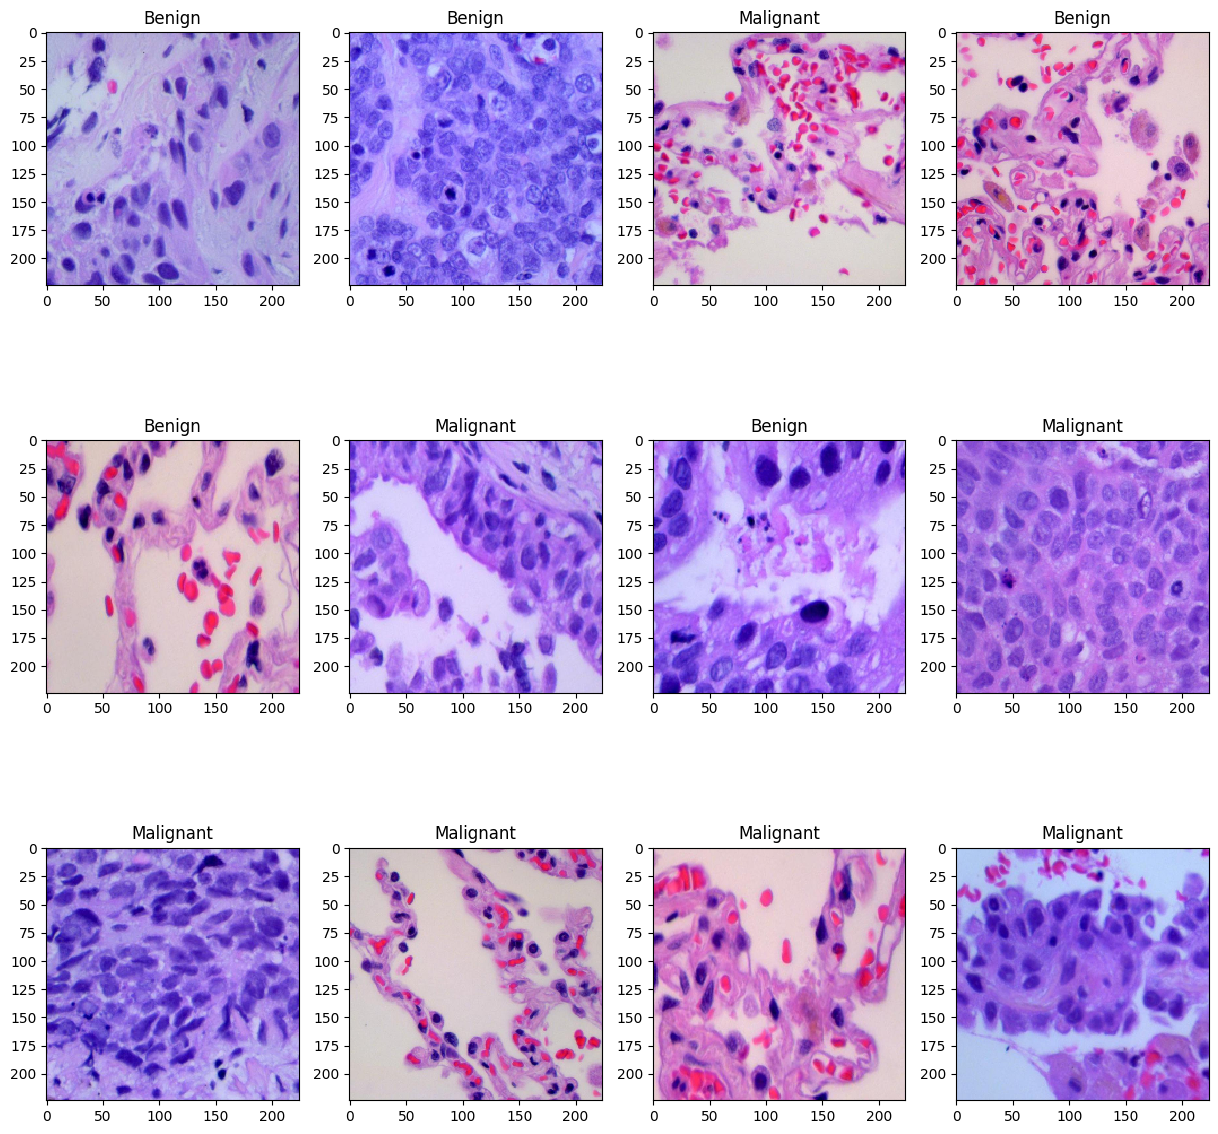

In [ ]:
# # Display first 15 images of moles, and how they are classified
w=60
h=40
fig=plt.figure(figsize=(15, 15))
columns = 4
rows = 3

for i in range(1, columns*rows +1):
    ax = fig.add_subplot(rows, columns, i)
    if np.argmax(Y_train[i]) == 0:
        ax.title.set_text('Benign')
    else:
        ax.title.set_text('Malignant')
    plt.imshow(x_train[i], interpolation='nearest')
plt.show()

In [ ]:
# DATA
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 3

# OPTIMIZER
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# TRAINING
EPOCHS = 20
# AUGMENTATION
IMAGE_SIZE = 224  # We will resize input images to this size.
PATCH_SIZE = 14 # Size of the patches to be extracted from the input images.
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

# ViT ARCHITECTURE
LAYER_NORM_EPS = 1e-6
PROJECTION_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
MLP_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM,
]

# TOKENLEARNER
NUM_TOKENS = 4

## Data augmentation

The augmentation pipeline consists of:

- Rescaling
- Resizing
- Random cropping (fixed-sized or random sized)
- Random horizontal flipping

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(x_train)


In [ ]:

def position_embedding(
    projected_patches, num_patches=NUM_PATCHES, projection_dim=PROJECTION_DIM
):
    # Build the positions.
    positions = tf.range(start=0, limit=num_patches, delta=1)

    # Encode the positions with an Embedding layer.
    encoded_positions = layers.Embedding(
        input_dim=num_patches, output_dim=projection_dim
    )(positions)

    # Add encoded positions to the projected patches.
    return projected_patches + encoded_positions


## MLP block for Transformer

This serves as the Fully Connected Feed Forward block for our Transformer.

In [ ]:

def mlp(x, dropout_rate, hidden_units):
    # Iterate over the hidden units and
    # add Dense => Dropout.
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.swish)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras.ops as ops # Changed: Import keras.ops for modern backend operations

def inverted_residual_block(x, expanded_channels, output_channels, strides=1):
    m = layers.Conv2D(expanded_channels, 1, padding="same", use_bias=False)(x)
    m = layers.BatchNormalization()(m)
    m = layers.Activation(tf.nn.swish)(m) # Corrected: Wrapped tf.nn.swish in a Keras Activation layer

    if strides == 2:
        m = layers.ZeroPadding2D(padding=(1, 3))(m)
    m = layers.DepthwiseConv2D(
        3, strides=strides, padding="same" if strides == 1 else "valid", use_bias=False
    )(m)
    m = layers.BatchNormalization()(m)
    m = layers.Activation(tf.nn.swish)(m) # Corrected: Wrapped tf.nn.swish in a Keras Activation layer

    m = layers.Conv2D(output_channels, 1, padding="same", use_bias=False)(m)
    m = layers.BatchNormalization()(m)

    if tf.math.equal(x.shape[-1], output_channels) and strides == 1:
        return layers.Add()([m, x])
    return m

def token_learner(inputs, number_of_tokens=4, kernel_size=(3, 3)):
    # Layer normalize the inputs.
    x = layers.LayerNormalization(epsilon=1e-5)(inputs)  # (B, H, W, C)

    # Applying Depthwise Conv2D => Pointwise Conv2D => BatchNormalization
    x = inverted_residual_block(x, number_of_tokens, number_of_tokens, strides=1)

    # Additional Conv2D layers for attention_maps
    attention_maps = tf.keras.Sequential(
        [
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            # This conv layer will generate the attention maps
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation="sigmoid",  # Note sigmoid for [0, 1] output
                padding="same",
                use_bias=False,
            ),
        ]
    )(x)  # (B, H, W, num_of_tokens)

    attention_maps = layers.Reshape((-1, number_of_tokens))(attention_maps)  # (B, H*W, num_of_tokens)
    attention_maps = layers.Permute((2, 1))(attention_maps)  # (B, num_of_tokens, H*W)

    # Reshape the input to align it with the output of the conv block.
    num_filters = inputs.shape[-1]
    inputs_reshaped = layers.Reshape((-1, num_filters))(inputs)  # inputs == (B, H*W, C)

    # Element-Wise multiplication of the attention maps and the inputs
    expanded_attention_maps = layers.Lambda(lambda x: ops.expand_dims(x, axis=-1))(attention_maps)
    expanded_inputs_reshaped = layers.Lambda(lambda x: ops.expand_dims(x, axis=1))(inputs_reshaped)
    attended_inputs = layers.Multiply()([expanded_attention_maps, expanded_inputs_reshaped])

    # Global average pooling the element-wise multiplication result.
    outputs = ops.mean(attended_inputs, axis=2)  # Corrected: Used keras.ops.mean
    return outputs

# Example usage:
input_tensor = layers.Input(shape=(224, 224, 3))
output_tensor = token_learner(input_tensor)

model = models.Model(inputs=input_tensor, outputs=output_tensor)


## Transformer block

In [ ]:

def transformer(encoded_patches):
    # Layer normalization 1.
    x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(encoded_patches)

    # Multi Head Self Attention layer 1.
    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=PROJECTION_DIM, dropout=0.2
    )(x1, x1)

    # Skip connection 1.
    x2 = layers.Add()([attention_output, encoded_patches])

    # Layer normalization 2.
    x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

    # MLP layer 1.
    x4 = mlp(x3, hidden_units=MLP_UNITS, dropout_rate=0.5)

    # Skip connection 2.
    encoded_patches = layers.Add()([x4, x2])
    return encoded_patches


In [ ]:

def create_vit_classifier(use_token_learner=True, token_learner_units=NUM_TOKENS):
    inputs = layers.Input(shape=INPUT_SHAPE)  # (B, H, W, C)

    # Augment data.
    augmented = data_augmentation(inputs)

    # Create patches and project the pathces.
    projected_patches = layers.Conv2D(
        filters=PROJECTION_DIM,
        kernel_size=(PATCH_SIZE, PATCH_SIZE),
        strides=(PATCH_SIZE, PATCH_SIZE),
        padding="VALID",
    )(augmented)
    _, h, w, c = projected_patches.shape
    projected_patches = layers.Reshape((h * w, c))(
        projected_patches
    )  # (B, number_patches, projection_dim)

    # Add positional embeddings to the projected patches.
    encoded_patches = position_embedding(
        projected_patches
    )  # (B, number_patches, projection_dim)
    encoded_patches = layers.Dropout(0.1)(encoded_patches)

    # Iterate over the number of layers and stack up blocks of
    # Transformer.
    for i in range(NUM_LAYERS):
        # Add a Transformer block.
        encoded_patches = transformer(encoded_patches)

        # Add TokenLearner layer in the middle of the
        # architecture. The paper suggests that anywhere
        # between 1/2 or 3/4 will work well.
        if use_token_learner and i == NUM_LAYERS // 2:
            _, hh, c = encoded_patches.shape
            h = int(math.sqrt(hh))
            encoded_patches = layers.Reshape((h, h, c))(
                encoded_patches
            )  # (B, h, h, projection_dim)
            encoded_patches = token_learner(
                encoded_patches, token_learner_units
            )  # (B, num_tokens, c)

    # Layer normalization and Global average pooling.
    representation = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(encoded_patches)
    representation = layers.GlobalAvgPool1D()(representation)

    # Classify outputs.
    outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(representation)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.summary()
    return model


In [ ]:
num_classes = 3
batch_size = 32
num_epochs = 20

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          7 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     75,392 │ data_augmentatio… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 256, 128)  │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 128)  │          0 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 128)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256, 128)  │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 128)  │          0 │ dropout_3[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 128)  │          0 │ multi_head_atten… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 737,966 (2.82 MB)

 Trainable params: 737,935 (2.81 MB)

 Non-trainable params: 31 (128.00 B)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


MODEL COMPLEXITY REPORT — TMViT (Lung_3class)
Trainable parameters:     737,935
Non-trainable parameters: 31
Total parameters:         737,966
Total FLOPs:              649,691,998
GFLOPs:                   0.6497
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/nn.py:1172: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


338/338 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.8812 - loss: 0.2944 - val_accuracy: 0.9217 - val_loss: 0.1983
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9243 - loss: 0.1880 - val_accuracy: 0.9292 - val_loss: 0.1725
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9368 - loss: 0.1545 - val_accuracy: 0.9301 - val_loss: 0.1632
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9458 - loss: 0.1363 - val_accuracy: 0.9592 - val_loss: 0.1074
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9517 - loss: 0.1251 - val_accuracy: 0.9417 - val_loss: 0.1545
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9550 - loss: 0.1156 - val_accuracy: 0.9342 - val_loss: 0.2313
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9608 - loss: 0.1072 - val_accuracy: 0.9692 - val_loss: 0.0845
Epoch 8/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9625 - loss: 0.1016 - val_accuracy: 0.96

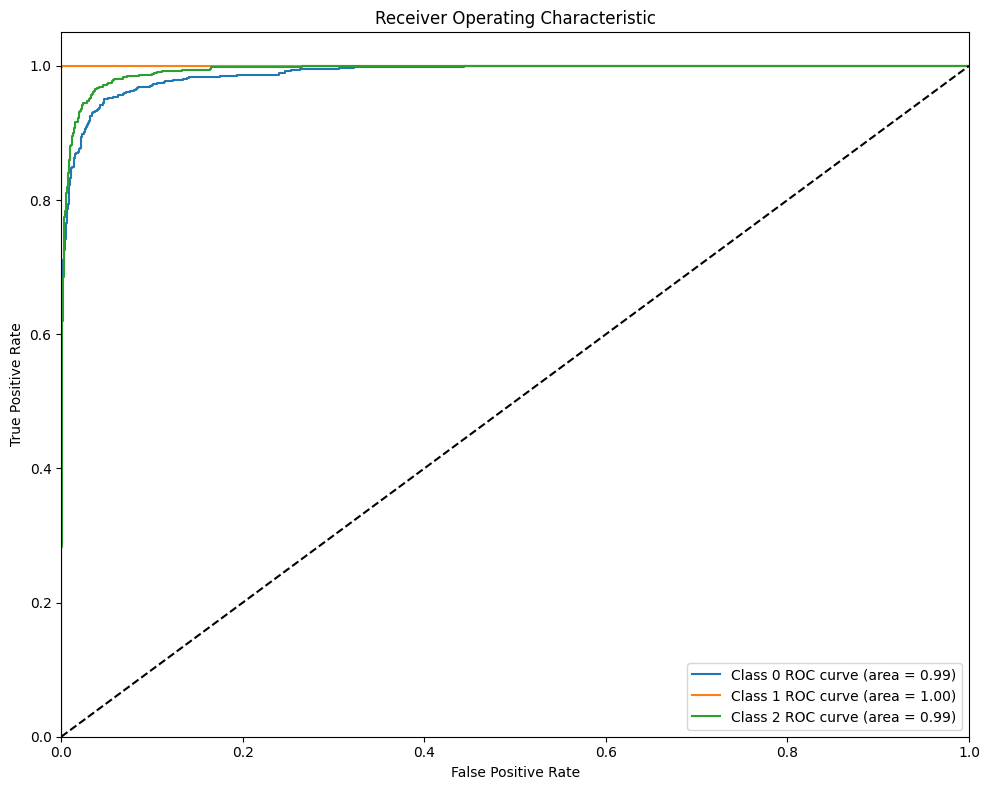

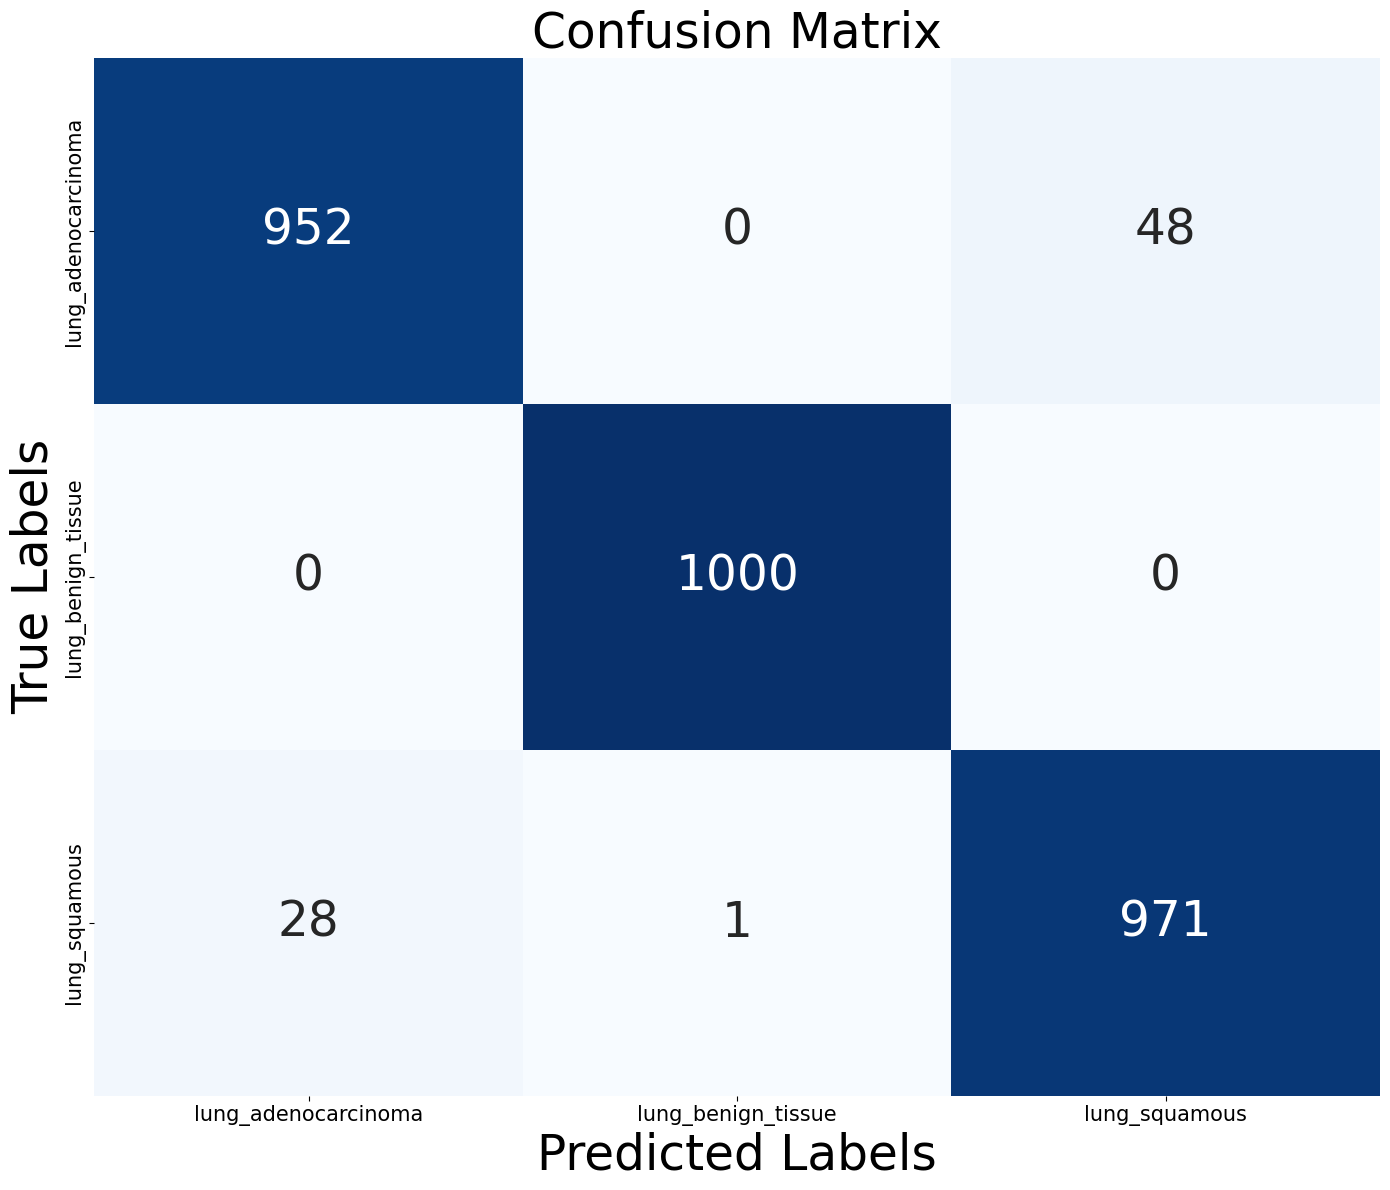

Confusion matrix and ROC curve saved to: /content/drive/MyDrive/SAVE_FIGS (dpi=600)
Class lung_adenocarcinoma - Precision: 0.9714285714285714, Sensitivity: 0.952, Specificity: 0.986, AUC: 0.9888835, F1 Score: 0.9616161616161616
Class lung_benign_tissue - Precision: 0.999000999000999, Sensitivity: 1.0, Specificity: 0.9995, AUC: 0.999999, F1 Score: 0.9995002498750625
Class lung_squamous - Precision: 0.9528949950932286, Sensitivity: 0.971, Specificity: 0.976, AUC: 0.9938075000000001, F1 Score: 0.9618623080733036
Mean Precision: 0.9744415218409331
Mean Sensitivity: 0.9743333333333334
Mean Specificity: 0.9871666666666666
Mean AUC: 0.99423
Mean F1 Score: 0.9743262398548426


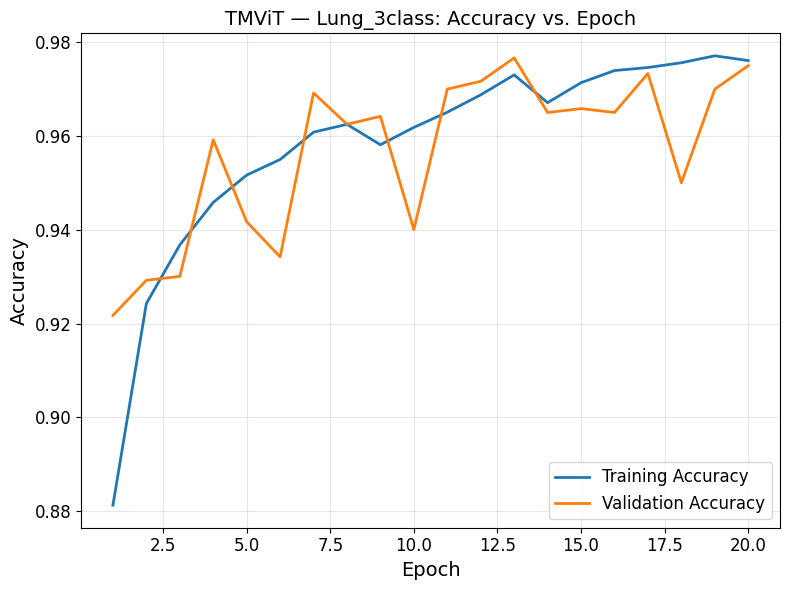

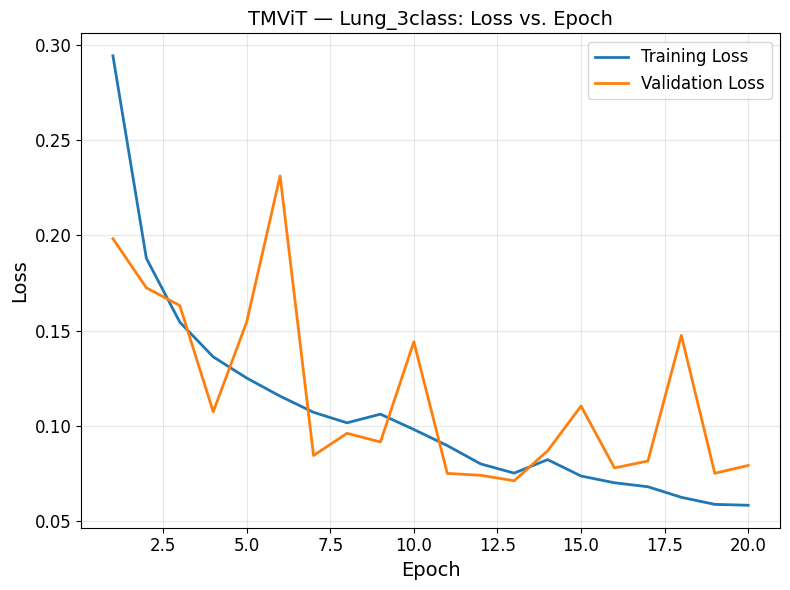

Learning-curve figures saved to: /content/drive/MyDrive/SAVE_FIGS (dpi=600)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score
from tensorflow import keras
import time
import os


from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2_as_graph,
)

# Where the complexity report / all figures are written.
FIGURES_DIR = "/content/drive/MyDrive/SAVE_FIGS"
FIGURE_DPI = 600
MODEL_NAME = "TMViT"
EXPERIMENT_NAME = "Lung_3class"

os.makedirs(FIGURES_DIR, exist_ok=True)


def compute_model_complexity(model, input_shape=(1, 224, 224, 3)):

    trainable_params = int(
        np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    )
    non_trainable_params = int(
        np.sum(
            [tf.keras.backend.count_params(w) for w in model.non_trainable_weights]
        )
    )
    total_params = trainable_params + non_trainable_params

    total_flops = None
    gflops = None
    try:

        concrete_func = tf.function(lambda x: model(x, training=False))
        concrete_func = concrete_func.get_concrete_function(
            tf.TensorSpec(input_shape, model.inputs[0].dtype)
        )
        frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(
            concrete_func
        )

        with tf.Graph().as_default() as graph:
            tf.graph_util.import_graph_def(graph_def, name="")
            run_meta = tf.compat.v1.RunMetadata()
            opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
            flops = tf.compat.v1.profiler.profile(
                graph=graph, run_meta=run_meta, cmd="op", options=opts
            )
            total_flops = flops.total_float_ops if flops is not None else None
        gflops = total_flops / 1e9 if total_flops is not None else None
    except Exception as e:
        print(f"[WARNING] GFLOPs computation failed: {e}")

    print("=" * 60)
    print(f"MODEL COMPLEXITY REPORT — {MODEL_NAME} ({EXPERIMENT_NAME})")
    print("=" * 60)
    print(f"Trainable parameters:     {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")
    print(f"Total parameters:         {total_params:,}")
    if gflops is not None:
        print(f"Total FLOPs:              {total_flops:,}")
        print(f"GFLOPs:                   {gflops:.4f}")
    else:
        print("GFLOPs:                   could not be computed")
    print("=" * 60)

    return {
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "total_params": total_params,
        "total_flops": total_flops,
        "gflops": gflops,
    }


def plot_learning_curves(
    history,
    model_name=MODEL_NAME,
    experiment_name=EXPERIMENT_NAME,
    out_dir=FIGURES_DIR,
    dpi=FIGURE_DPI,
):

    hist = history.history

    # --- Accuracy curve ---
    plt.figure(figsize=(8, 6))
    if "accuracy" in hist:
        plt.plot(range(1, len(hist["accuracy"]) + 1), hist["accuracy"],
                  label="Training Accuracy", linewidth=2)
    if "val_accuracy" in hist:
        plt.plot(range(1, len(hist["val_accuracy"]) + 1), hist["val_accuracy"],
                  label="Validation Accuracy", linewidth=2)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    plt.title(f"{model_name} — {experiment_name}: Accuracy vs. Epoch", fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    acc_path = os.path.join(out_dir, f"{model_name}_{experiment_name}_accuracy_curve.png")
    plt.savefig(acc_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

    # --- Loss curve ---
    if "loss" in hist:
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, len(hist["loss"]) + 1), hist["loss"],
                  label="Training Loss", linewidth=2)
        if "val_loss" in hist:
            plt.plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"],
                      label="Validation Loss", linewidth=2)
        plt.xlabel("Epoch", fontsize=14)
        plt.ylabel("Loss", fontsize=14)
        plt.title(f"{model_name} — {experiment_name}: Loss vs. Epoch", fontsize=14)
        plt.legend(loc="upper right", fontsize=12)
        plt.grid(alpha=0.3)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.tight_layout()
        loss_path = os.path.join(out_dir, f"{model_name}_{experiment_name}_loss_curve.png")
        plt.savefig(loss_path, dpi=dpi, bbox_inches="tight")
        plt.show()
        plt.close()

    print(f"Learning-curve figures saved to: {out_dir} (dpi={dpi})")


def run_experiment(model, model_name=MODEL_NAME, experiment_name=EXPERIMENT_NAME,
                    out_dir=FIGURES_DIR, dpi=FIGURE_DPI):
    optimizer = 'adam'

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    checkpoint_filepath = "/content/drive/MyDrive/SAVE/b.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    start_time = time.time()
    history = model.fit(
        x=X_train,
        y=Y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )
    end_time = time.time()

    model.load_weights(checkpoint_filepath)
    _, accuracy = model.evaluate(X_test, Y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    total_training_time = end_time - start_time
    avg_training_time_per_epoch = total_training_time / EPOCHS
    print("Total Training Time (s):", total_training_time)
    print("Average Training Time per Epoch (s):", avg_training_time_per_epoch)

    Y_pred = model.predict(X_test)

    cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))
    true_positives = np.diag(cm)
    false_positives = np.sum(cm, axis=0) - true_positives
    false_negatives = np.sum(cm, axis=1) - true_positives
    true_negatives = np.sum(cm) - (true_positives + false_positives + false_negatives)

    precision = true_positives / (true_positives + false_positives)
    sensitivity = true_positives / (true_positives + false_negatives)
    specificity = true_negatives / (true_negatives + false_positives)

    # --- ROC curves, per class, saved at 600 dpi ---
    aucs = []
    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
        auc = roc_auc_score(Y_test[:, i], Y_pred[:, i])
        aucs.append(auc)
        plt.plot(fpr, tpr, label=f'Class {i} ROC curve (area = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right", prop={'size': 10})
    plt.tight_layout()
    roc_path = os.path.join(out_dir, f"{model_name}_{experiment_name}_roc_curve.png")
    plt.savefig(roc_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

    f1_scores = f1_score(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1), average=None)
    mean_f1_score = np.mean(f1_scores)

    # --- Confusion matrix, saved at 600 dpi ---
    classes = ['lung_adenocarcinoma', 'lung_benign_tissue', 'lung_squamous']
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 35})
    plt.title("Confusion Matrix", size=35)
    plt.xlabel("Predicted Labels", size=35)
    plt.ylabel("True Labels", size=35)
    plt.xticks(ticks=np.arange(NUM_CLASSES) + 0.5, labels=classes, size=15)
    plt.yticks(ticks=np.arange(NUM_CLASSES) + 0.5, labels=classes, size=15)
    plt.tight_layout()
    cm_path = os.path.join(out_dir, f"{model_name}_{experiment_name}_confusion_matrix.png")
    plt.savefig(cm_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Confusion matrix and ROC curve saved to: {out_dir} (dpi={dpi})")

    for i, class_name in enumerate(classes):
        print(f"Class {class_name} - Precision: {precision[i]}, Sensitivity: {sensitivity[i]}, "
              f"Specificity: {specificity[i]}, AUC: {aucs[i]}, F1 Score: {f1_scores[i]}")

    print("Mean Precision:", np.mean(precision))
    print("Mean Sensitivity:", np.mean(sensitivity))
    print("Mean Specificity:", np.mean(specificity))
    print("Mean AUC:", np.mean(aucs))
    print("Mean F1 Score:", mean_f1_score)

    return history


vit_classifier = create_vit_classifier()


complexity_report = compute_model_complexity(vit_classifier, input_shape=(1,) + INPUT_SHAPE)

history = run_experiment(vit_classifier)

plot_learning_curves(history, model_name=MODEL_NAME, experiment_name=EXPERIMENT_NAME)